In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from xgboost import XGBClassifier
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
df = pd.read_csv('hospital_readmissions.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget value counts:")
print(df['readmitted'].value_counts())
print("\nData types:")
print(df.dtypes)
display(df.head(3))

Shape: (25000, 17)

Columns: ['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted']

Target value counts:
readmitted
no     13246
yes    11754
Name: count, dtype: int64

Data types:
age                    str
time_in_hospital     int64
n_lab_procedures     int64
n_procedures         int64
n_medications        int64
n_outpatient         int64
n_inpatient          int64
n_emergency          int64
medical_specialty      str
diag_1                 str
diag_2                 str
diag_3                 str
glucose_test           str
A1Ctest                str
change                 str
diabetes_med           str
readmitted             str
dtype: object


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64


In [4]:
cat_cols = ['age', 'medical_specialty', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


age:
age
[70-80)     6837
[60-70)     5913
[80-90)     4516
[50-60)     4452
[40-50)     2532
[90-100)     750
Name: count, dtype: int64

medical_specialty:
medical_specialty
Missing                   12382
InternalMedicine           3565
Other                      2664
Emergency/Trauma           1885
Family/GeneralPractice     1882
Cardiology                 1409
Surgery                    1213
Name: count, dtype: int64

glucose_test:
glucose_test
no        23625
normal      689
high        686
Name: count, dtype: int64

A1Ctest:
A1Ctest
no        20938
high       2827
normal     1235
Name: count, dtype: int64

change:
change
no     13497
yes    11503
Name: count, dtype: int64

diabetes_med:
diabetes_med
yes    19228
no      5772
Name: count, dtype: int64


In [5]:
df_clean = df.copy()

# Drop diagnosis columns (too many unique values, too noisy)
df_clean = df_clean.drop(columns=['diag_1', 'diag_2', 'diag_3'])

# Fix target FIRST — this was the bug before
df_clean['readmitted'] = df_clean['readmitted'].map({'yes': 1, 'no': 0})
print("Target distribution after encoding:")
print(df_clean['readmitted'].value_counts())

# Encode age
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
df_clean['age'] = df_clean['age'].apply(
    lambda x: age_order.index(x) if x in age_order else -1
)

# Encode all remaining string columns
cat_cols = ['medical_specialty', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\n{col} encoding: {encoders[col]}")

print("\n✅ Encoding done!")
print(df_clean.dtypes)

Target distribution after encoding:
readmitted
0    13246
1    11754
Name: count, dtype: int64

medical_specialty encoding: {'Cardiology': np.int64(0), 'Emergency/Trauma': np.int64(1), 'Family/GeneralPractice': np.int64(2), 'InternalMedicine': np.int64(3), 'Missing': np.int64(4), 'Other': np.int64(5), 'Surgery': np.int64(6)}

glucose_test encoding: {'high': np.int64(0), 'no': np.int64(1), 'normal': np.int64(2)}

A1Ctest encoding: {'high': np.int64(0), 'no': np.int64(1), 'normal': np.int64(2)}

change encoding: {'no': np.int64(0), 'yes': np.int64(1)}

diabetes_med encoding: {'no': np.int64(0), 'yes': np.int64(1)}

✅ Encoding done!
age                  int64
time_in_hospital     int64
n_lab_procedures     int64
n_procedures         int64
n_medications        int64
n_outpatient         int64
n_inpatient          int64
n_emergency          int64
medical_specialty    int64
glucose_test         int64
A1Ctest              int64
change               int64
diabetes_med         int64
readmitted 

In [6]:
print("Any nulls?", df_clean.isnull().sum().sum())
print("Shape:", df_clean.shape)
display(df_clean.head(3))

Any nulls? 0
Shape: (25000, 14)


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,7,8,72,1,18,2,0,0,4,1,1,0,1,0
1,7,3,34,2,13,0,0,0,5,1,1,0,1,0
2,5,5,45,0,18,0,0,0,4,1,1,1,1,1


In [7]:
X = df_clean.drop(columns=['readmitted'])
y = df_clean['readmitted']

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

Features: ['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'medical_specialty', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']
X shape: (25000, 13)
y distribution:
 readmitted
0    13246
1    11754
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nTrain target distribution:\n{y_train.value_counts()}")

Train size: (20000, 13)
Test size:  (5000, 13)

Train target distribution:
readmitted
0    10597
1     9403
Name: count, dtype: int64


In [9]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)
print("✅ Model trained!")

✅ Model trained!


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.63      0.67      0.65      2649
           1       0.60      0.55      0.57      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.61      0.61      0.61      5000

ROC-AUC Score: 0.6509


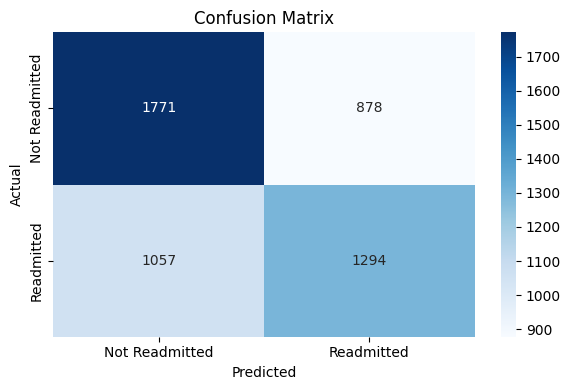

In [10]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

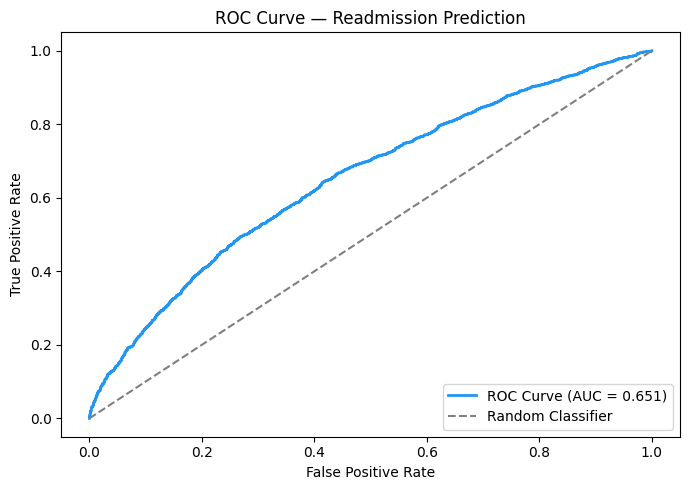

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#2196F3', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Readmission Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

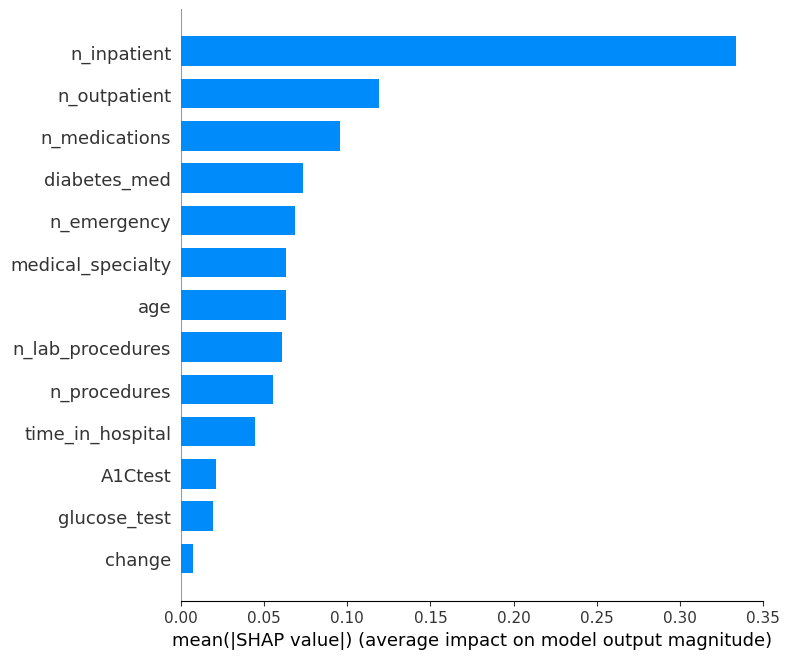

In [12]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

In [13]:
sample      = X_test.iloc[0:5]
all_probs   = model.predict_proba(X_test)[:, 1]

print("Sample predictions:")
print(model.predict_proba(sample))

print(f"\nMin prob:  {all_probs.min():.4f}")
print(f"Max prob:  {all_probs.max():.4f}")
print(f"Mean prob: {all_probs.mean():.4f}")


Sample predictions:
[[0.52675086 0.47324914]
 [0.648273   0.35172698]
 [0.5077567  0.49224326]
 [0.55276    0.44723997]
 [0.5728261  0.4271739 ]]

Min prob:  0.1082
Max prob:  0.9808
Mean prob: 0.4985


In [14]:
joblib.dump(model,    'readmission_model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_features.pkl')
joblib.dump(encoders, 'encoders.pkl')

print("✅ Model saved!")
print("✅ Features saved!")
print("✅ Encoders saved!")

✅ Model saved!
✅ Features saved!
✅ Encoders saved!


In [15]:
# Print all encoder mappings so app.py uses exact same values
for col, mapping in encoders.items():
    print(f"\n{col}: {mapping}")

print("\nAge order used:")
print(age_order)

print("\nFeature columns:")
print(X_train.columns.tolist())


medical_specialty: {'Cardiology': np.int64(0), 'Emergency/Trauma': np.int64(1), 'Family/GeneralPractice': np.int64(2), 'InternalMedicine': np.int64(3), 'Missing': np.int64(4), 'Other': np.int64(5), 'Surgery': np.int64(6)}

glucose_test: {'high': np.int64(0), 'no': np.int64(1), 'normal': np.int64(2)}

A1Ctest: {'high': np.int64(0), 'no': np.int64(1), 'normal': np.int64(2)}

change: {'no': np.int64(0), 'yes': np.int64(1)}

diabetes_med: {'no': np.int64(0), 'yes': np.int64(1)}

Age order used:
['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

Feature columns:
['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'medical_specialty', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']
